In [5]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

In [6]:
# Read the Traffic Dataset
traffic = pd.read_csv(r"C:\Users\ADMIN\Downloads\Integrated_Dataset_FINAL.csv")


In [7]:

traffic

,DateTime,Junction,Vehicles,ID,date,hour,temperature_avg,humidity_avg,wind_speed,precipitation,event_flag,event_name
0,01-11-2015 00:00,1,15,20151101001,01-11-2015,0,29.5,42.2,8.7,10,1,Weekend
1,01-11-2015 01:00,1,13,20151101011,01-11-2015,1,29.5,42.2,8.7,10,1,Weekend
2,01-11-2015 02:00,1,10,20151101021,01-11-2015,2,29.5,42.2,8.7,10,1,Weekend
3,01-11-2015 03:00,1,7,20151101031,01-11-2015,3,29.5,42.2,8.7,10,1,Weekend
4,01-11-2015 04:00,1,9,20151101041,01-11-2015,4,29.5,42.2,8.7,10,1,Weekend
...,...,...,...,...,...,...,...,...,...,...,...,...
48115,30-06-2017 19:00,4,11,20170630194,30-06-2017,19,24.3,72.5,8.7,0,0,NaN
48116,30-06-2017 20:00,4,30,20170630204,30-06-2017,20,24.3,72.5,8.7,0,0,NaN
48117,30-06-2017 21:00,4,16,20170630214,30-06-2017,21,24.3,72.5,8.7,0,0,NaN
48118,30-06-2017 22:00,4,22,20170630224,30-06-2017,22,24.3,72.5,8.7,0,0,NaN


In [8]:
# Check the null values and sum of those values in each column.
traffic.isna().sum()

DateTime               0
Junction               0
Vehicles               0
ID                     0
date                   0
hour                   0
temperature_avg        0
humidity_avg           0
wind_speed             0
precipitation          0
event_flag             0
event_name         33288
dtype: int64

In [9]:
# If their is any null value fill those with None.
traffic['event_name'] = traffic['event_name'].fillna("None")


In [10]:
traffic.isna().sum()

DateTime           0
Junction           0
Vehicles           0
ID                 0
date               0
hour               0
temperature_avg    0
humidity_avg       0
wind_speed         0
precipitation      0
event_flag         0
event_name         0
dtype: int64

In [11]:
# Drop duplicate values
traffic.drop_duplicates(inplace = True)

In [12]:
#Convrt string date into date format
traffic['DateTime'] = pd.to_datetime(traffic['DateTime'], format="%d-%m-%Y %H:%M")

# Create date and hour column from Datetime
traffic['date'] = traffic['DateTime'].dt.date
traffic['hour'] = traffic['DateTime'].dt.hour


In [13]:
#Read the data in dataframe.
traffic_hourly = traffic.groupby(['date', 'hour', 'Junction'])['Vehicles'].sum().reset_index()
traffic_hourly

,date,hour,Junction,Vehicles
0,2015-11-01,0,1,15
1,2015-11-01,0,2,6
2,2015-11-01,0,3,9
3,2015-11-01,1,1,13
4,2015-11-01,1,2,6
...,...,...,...,...
48115,2017-06-30,22,4,22
48116,2017-06-30,23,1,78
48117,2017-06-30,23,2,27
48118,2017-06-30,23,3,39


In [14]:
# install scikit - learn
!pip install scikit-learn
 
#Scikit-learn is a machine learning library in Python.
#It helps you build models, analyze data, and make predictions easily.



[notice] A new release of pip is available: 25.2 -> 25.3
[notice] To update, run: python.exe -m pip install --upgrade pip


In [15]:
# Apply StandardScaler to normalize the selected numerical columns.
# This helps improve model performance by ensuring all features have the same scale (mean=0, std=1).


from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
traffic[['Vehicles','temperature_avg','humidity_avg','wind_speed']] = scaler.fit_transform(
    traffic[['Vehicles','temperature_avg','humidity_avg','wind_speed']]
)


In [16]:
traffic

,DateTime,Junction,Vehicles,ID,date,hour,temperature_avg,humidity_avg,wind_speed,precipitation,event_flag,event_name
0,2015-11-01 00:00:00,1,-0.375489,20151101001,2015-11-01,0,0.531634,-1.861620,-0.711414,10,1,Weekend
1,2015-11-01 01:00:00,1,-0.471875,20151101011,2015-11-01,1,0.531634,-1.861620,-0.711414,10,1,Weekend
2,2015-11-01 02:00:00,1,-0.616454,20151101021,2015-11-01,2,0.531634,-1.861620,-0.711414,10,1,Weekend
3,2015-11-01 03:00:00,1,-0.761034,20151101031,2015-11-01,3,0.531634,-1.861620,-0.711414,10,1,Weekend
4,2015-11-01 04:00:00,1,-0.664648,20151101041,2015-11-01,4,0.531634,-1.861620,-0.711414,10,1,Weekend
...,...,...,...,...,...,...,...,...,...,...,...,...
48115,2017-06-30 19:00:00,4,-0.568261,20170630194,2017-06-30,19,-1.245023,1.166812,-0.711414,0,0,None
48116,2017-06-30 20:00:00,4,0.347408,20170630204,2017-06-30,20,-1.245023,1.166812,-0.711414,0,0,None
48117,2017-06-30 21:00:00,4,-0.327296,20170630214,2017-06-30,21,-1.245023,1.166812,-0.711414,0,0,None
48118,2017-06-30 22:00:00,4,-0.038137,20170630224,2017-06-30,22,-1.245023,1.166812,-0.711414,0,0,None


In [17]:
#Create hour, Day, month from Datetime.
traffic['hour'] = traffic['DateTime'].dt.hour

In [18]:
traffic['Day_of_Week'] = traffic['DateTime'].dt.dayofweek


In [19]:
traffic['month'] = traffic['DateTime'].dt.month

In [20]:
 # Create a new column with previous hour's vehicle count

traffic['lag_1'] = traffic['Vehicles'].shift(1)

In [21]:
# Create a new column with previous hour's vehicle count
traffic['lag_24'] = traffic['Vehicles'].shift(24)

In [22]:
# Drop null values
traffic = traffic.dropna()

In [23]:
# Create a binary indicator for weekends (Saturday=5, Sunday=6)
traffic.loc[:, 'is_weekend'] = (traffic['Day_of_Week'] >= 5).astype(int)


C:\Users\ADMIN\AppData\Local\Temp\ipykernel_8196\2783356518.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  traffic.loc[:, 'is_weekend'] = (traffic['Day_of_Week'] >= 5).astype(int)


In [24]:
# Create a binary indicator for special events (1 = event day, 0 = normal day)
traffic.loc[:, 'is_event'] = (traffic['event_flag'] == 1).astype(int)


C:\Users\ADMIN\AppData\Local\Temp\ipykernel_8196\2073062182.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  traffic.loc[:, 'is_event'] = (traffic['event_flag'] == 1).astype(int)


In [25]:
# Calculate correlation of all numeric features with the target variable 'Vehicles'
traffic.corr(numeric_only=True)['Vehicles']



Junction          -0.614320
Vehicles           1.000000
ID                 0.227774
hour               0.219938
temperature_avg    0.000020
humidity_avg      -0.003837
wind_speed        -0.009754
precipitation      0.005176
event_flag        -0.155758
Day_of_Week       -0.125773
month             -0.022420
lag_1              0.969982
lag_24             0.901522
is_weekend        -0.150304
is_event          -0.155758
Name: Vehicles, dtype: float64

In [26]:
# Import Random Forest model for feature importance and train_test_split for splitting data into train and test sets
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import train_test_split


In [27]:
# Select input features (X) and target variable (y) for the model

X = traffic[['hour','Day_of_Week','month','temperature_avg','humidity_avg',
             'wind_speed','is_weekend','is_event','lag_1','lag_24','Junction']]
y = traffic['Vehicles']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

model = RandomForestRegressor()
model.fit(X_train, y_train)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",100
,"criterion criterion: {""squared_error"", ""absolute_error"", ""friedman_mse"", ""poisson""}, default=""squared_error""The function to measure the quality of a split. Supported criteriaare ""squared_error"" for the mean squared error, which is equal tovariance reduction as feature selection criterion and minimizes the L2loss using the mean of each terminal node, ""friedman_mse"", which usesmean squared error with Friedman's improvement score for potentialsplits, ""absolute_error"" for the mean absolute error, which minimizesthe L1 loss using the median of each terminal node, and ""poisson"" whichuses reduction in Poisson deviance to find splits.Training using ""absolute_error"" is significantly slowerthan when using ""squared_error""... versionadded:: 0.18 Mean Absolute Error (MAE) criterion... versionadded:: 1.0 Poisson criterion.",'squared_error'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=1.0The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None or 1.0, then `max_features=n_features`... note:: The default of 1.0 is equivalent to bagged trees and more randomness can be achieved by setting smaller values, e.g. 0.3... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to 1.0.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",1.0
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsample

In [28]:
# Retrieve and display the importance of each feature as learned by the Random Forest model

importance = pd.Series(model.feature_importances_, index=X.columns)
print(importance.sort_values(ascending=False))

lag_1              0.941286
lag_24             0.016768
hour               0.014496
humidity_avg       0.005742
wind_speed         0.005013
temperature_avg    0.004951
month              0.003920
Day_of_Week        0.003425
Junction           0.002997
is_event           0.000799
is_weekend         0.000603
dtype: float64


In [29]:
traffic.columns

Index(['DateTime', 'Junction', 'Vehicles', 'ID', 'date', 'hour',
       'temperature_avg', 'humidity_avg', 'wind_speed', 'precipitation',
       'event_flag', 'event_name', 'Day_of_Week', 'month', 'lag_1', 'lag_24',
       'is_weekend', 'is_event'],
      dtype='object')

In [30]:
# Group traffic data by day of the week and hour to analyze hourly congestion patterns
hourly_congection = traffic.groupby(['Day_of_Week','hour'])['Vehicles'].mean()
hourly_congection

Day_of_Week  hour
0            0      -0.123944
             1      -0.304123
             2      -0.401684
             3      -0.463983
             4      -0.512848
                       ...   
6            19     -0.001234
             20      0.052689
             21      0.008371
             22      0.005170
             23     -0.027521
Name: Vehicles, Length: 168, dtype: float64

This output shows the average traffic congestion (vehicle count) for each hour across different days of the week. The values represent relative traffic levels, where positive values indicate above-average congestion and negative values indicate below-average congestion.

In [31]:
#Calculate average traffic volume for each hour of the day and sort to identify peak hours
hourly_avg = traffic.groupby('hour')['Vehicles'].mean()
hourly_avg.sort_values(ascending=False)



hour
19    0.340651
20    0.339280
12    0.270790
21    0.261026
18    0.255880
14    0.236978
15    0.234549
11    0.226949
22    0.213939
16    0.187486
17    0.186139
23    0.137321
13    0.135060
10    0.069552
0     0.036317
1    -0.150996
9    -0.164247
2    -0.273980
8    -0.307744
3    -0.382655
7    -0.389629
6    -0.472741
4    -0.473077
5    -0.511555
Name: Vehicles, dtype: float64

This output shows the average traffic volume for each hour of the day, sorted in descending order to identify hours with the highest congestion.

In [32]:
# Apply a 3-hour moving average to smooth hourly traffic values and identify consistent peak periods
moving_avg = hourly_avg.rolling(window=3).mean()
moving_avg


hour
0          NaN
1          NaN
2    -0.129553
3    -0.269211
4    -0.376571
5    -0.455763
6    -0.485791
7    -0.457975
8    -0.390038
9    -0.287207
10   -0.134146
11    0.044085
12    0.189097
13    0.210933
14    0.214276
15    0.202195
16    0.219671
17    0.202725
18    0.209835
19    0.260890
20    0.311937
21    0.313652
22    0.271415
23    0.204095
Name: Vehicles, dtype: float64

Using a 3-hour moving average helps reduce random spikes in traffic data and reveals stable peak periods. Consistently higher moving-average values indicate sustained peak hours, while lower values indicate off-peak per

In [33]:
hourly_avg.std()


np.float64(0.29387578385701846)

This value represents how much traffic volume varies across different hours of the day.

In [34]:
# Calculate average hourly traffic separately for weekdays and weekends to compare congestion patterns
weekday_weekend_pattern = traffic.groupby(['is_weekend','hour'])['Vehicles'].mean()
weekday_weekend_pattern


is_weekend  hour
0           0       0.077493
            1      -0.110645
            2      -0.235141
            3      -0.347278
            4      -0.443060
            5      -0.477316
            6      -0.427846
            7      -0.330822
            8      -0.247500
            9      -0.090461
            10      0.186608
            11      0.383578
            12      0.437783
            13      0.270433
            14      0.416020
            15      0.417229
            16      0.349322
            17      0.339449
            18      0.400370
            19      0.462568
            20      0.418136
            21      0.336359
            22      0.287964
            23      0.203971
1           0      -0.067527
            1      -0.252761
            2      -0.371931
            3      -0.471875
            4      -0.548781
            5      -0.597906
            6      -0.585963
            7      -0.537939
            8      -0.459679
            9      -0.3503

This output shows the average traffic volume for each hour, separately for weekdays (is_weekend = 0) and weekends (is_weekend = 1).

In [35]:
#Calculate average hourly traffic for each month to examine monthly and seasonal congestion patterns
monthly_pattern = traffic.groupby(['month','hour'])['Vehicles'].mean()
monthly_pattern


month  hour
1      0      -0.125862
       1      -0.283544
       2      -0.383928
       3      -0.441893
       4      -0.527619
                 ...   
12     19      0.049958
       20      0.072241
       21      0.039594
       22      0.004097
       23     -0.092289
Name: Vehicles, Length: 288, dtype: float64

This output shows the average traffic volume for each hour across different months.

In [36]:
# Perform correlation analysis to examine the relationship between traffic volume and weather/event factors

traffic[['Vehicles',
         'temperature_avg',
         'humidity_avg',
         'wind_speed',
         'precipitation',
         'is_event']].corr(numeric_only=True)['Vehicles']


Vehicles           1.000000
temperature_avg    0.000020
humidity_avg      -0.003837
wind_speed        -0.009754
precipitation      0.005176
is_event          -0.155758
Name: Vehicles, dtype: float64

“The correlation results indicate that weather variables (temperature, humidity, wind speed, and precipitation) have very weak relationships with traffic volume, suggesting minimal influence on congestion. The event indicator shows a relatively stronger correlation compared to weather variables, indicating that special events have a more noticeable impact on traffic levels.”

In [37]:
# Import Linear Regression model.
from sklearn.linear_model import LinearRegression

# Select weather variables and event indicator as input features
X = traffic[['temperature_avg','humidity_avg','wind_speed','precipitation','is_event']]

# Target variable representing traffic volume
y = traffic['Vehicles']

# Train a linear regression model
model = LinearRegression()
model.fit(X, y)

# Display regression coefficients to assess the influence of each factor
pd.Series(model.coef_, index=X.columns)


temperature_avg    0.000405
humidity_avg       0.001928
wind_speed        -0.010832
precipitation      0.000456
is_event          -0.337748
dtype: float64

The regression results show that weather factors such as temperature, humidity, wind speed, and rainfall have very little effect on traffic congestion. However, special events have a more noticeable impact on traffic levels. Regression analysis is more reliable because it considers the combined effect of all factors together.

In [38]:
import matplotlib.pyplot as plt

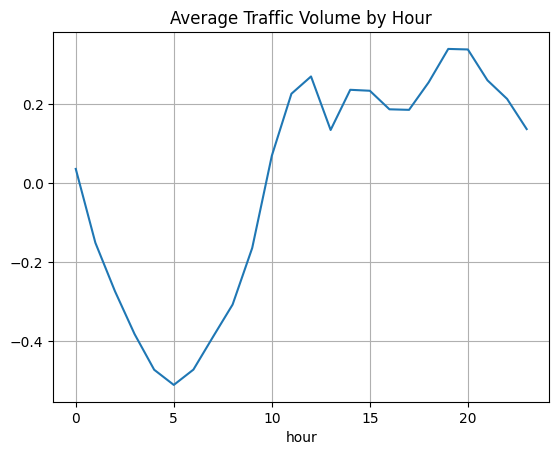

In [39]:
# Line graph showing average traffic volume for each hour of the day
hourly_avg = traffic.groupby('hour')['Vehicles'].mean()
hourly_avg.plot(kind = 'line', title = 'Average Traffic Volume by Hour')
plt.grid()

The line graph illustrates the average traffic volume across different hours of the day. Traffic is lowest during late-night and early-morning hours, increases significantly during morning commute hours, remains moderate during midday, and peaks during evening hours. This pattern clearly highlights typical urban traffic behavior with distinct morning and evening rush hours

In [40]:
heatmap_data = traffic.pivot_table(
    values = 'Vehicles',
    index = 'Day_of_Week',
    columns = 'hour',
    aggfunc = 'mean'

)


In [41]:
heatmap_data

hour,0,1,2,3,4,5,6,7,8,9,...,14,15,16,17,18,19,20,21,22,23
Day_of_Week,,,,,,,,,,,,,,,,,,,,,
0,-0.123944,-0.304123,-0.401684,-0.463983,-0.512848,-0.529136,-0.472043,-0.362055,-0.277927,-0.103122,...,0.457228,0.457228,0.382168,0.371589,0.418271,0.491820,0.437246,0.366719,0.323731,0.236581
1,0.111480,-0.063829,-0.183556,-0.308153,-0.414446,-0.461800,-0.401348,-0.305130,-0.221674,-0.078270,...,0.431368,0.440268,0.385190,0.384351,0.441779,0.494338,0.446649,0.364872,0.316511,0.220964
2,0.133310,-0.050395,-0.181205,-0.304458,-0.424521,-0.459785,-0.411088,-0.320915,-0.230909,-0.078606,...,0.418438,0.417935,0.335822,0.348248,0.400471,0.471837,0.455381,0.382336,0.339684,0.237252
3,0.126425,-0.071049,-0.199508,-0.320915,-0.420995,-0.458106,-0.412935,-0.324273,-0.244847,-0.094894,...,0.435734,0.434559,0.374275,0.364200,0.442787,0.502399,0.448328,0.349087,0.303413,0.228688
4,0.140194,-0.063829,-0.209751,-0.338882,-0.442489,-0.477752,-0.441817,-0.341737,-0.262143,-0.097413,...,0.337333,0.336157,0.269157,0.228856,0.298543,0.352446,0.303077,0.218781,0.156483,0.096367
5,0.026064,-0.169604,-0.298686,-0.425555,-0.518876,-0.574903,-0.569283,-0.524325,-0.447353,-0.338194,...,-0.191912,-0.207068,-0.204514,-0.197362,-0.115961,0.067956,0.229054,0.134371,0.049564,-0.034050
6,-0.160136,-0.335047,-0.444408,-0.517709,-0.578372,-0.620667,-0.602468,-0.551411,-0.471875,-0.362345,...,-0.236976,-0.245064,-0.236639,-0.203611,-0.101159,-0.001234,0.052689,0.008371,0.005170,-0.027521


In [42]:
import plotly.express as px

fig = px.imshow(
    heatmap_data,
    labels=dict(x="Hour of Day", y="Day of Week", color="Avg Traffic"),
    x=heatmap_data.columns,
    y=heatmap_data.index,
    color_continuous_scale="YlOrRd",
    title="Traffic Congestion Heatmap (Day of Week vs Hour)"
)
fig.show()


The heatmap visualizes traffic congestion across different days of the week and hours of the day. Darker color intensities indicate higher congestion levels, which are primarily observed during daytime and evening hours on weekdays. Weekends show comparatively lower congestion with shifted peak periods. This visualization clearly highlights daily and weekly traffic patterns.

In [43]:


# Create pivot table for month vs hour
monthly_heatmap = traffic.pivot_table(
    values='Vehicles',
    index='month',
    columns='hour',
    aggfunc='mean'
)

# Create  heatmap
fig = px.imshow(
    monthly_heatmap,
    labels=dict(x="Hour of Day", y="Month", color="Avg Traffic"),
    color_continuous_scale="YlOrRd",
    title="Traffic Congestion Heatmap (Month vs Hour)"
)

fig.show()


The month–hour heatmap shows average traffic congestion across different months and hours of the day. Peak traffic hours remain largely consistent throughout the year, typically occurring during daytime and evening hours. While minor variations in traffic intensity are observed between months, no significant seasonal shift in peak hours is evident.

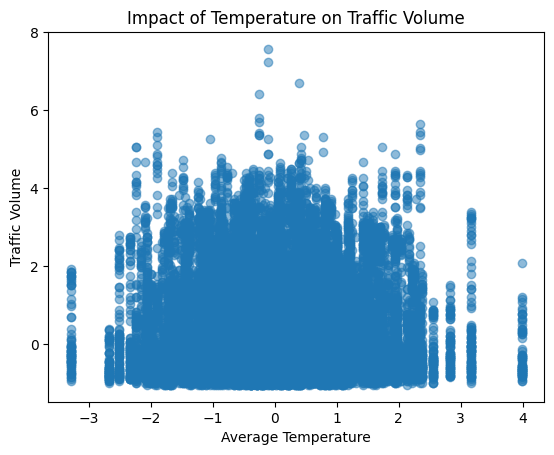

In [44]:
#Highlight the impact of external factors on peak hours through scatter plots or line charts.

plt.scatter(traffic['temperature_avg'],traffic['Vehicles'], alpha = 0.5)
plt.xlabel("Average Temperature")
plt.ylabel("Traffic Volume")
plt.title('Impact of Temperature on Traffic Volume')
plt.show()

The scatter plot shows a weak relationship between temperature and traffic volume, indicating that weather conditions have minimal impact on peak traffic hours

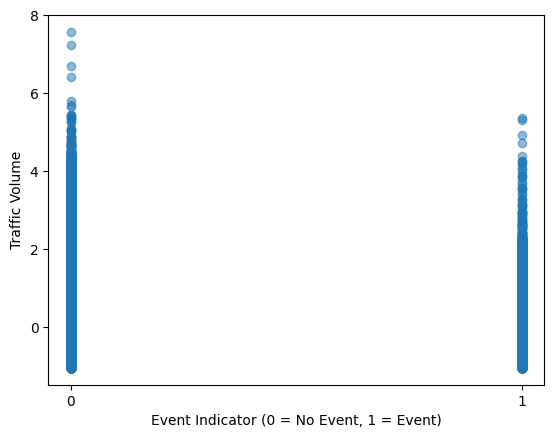

In [45]:
plt.scatter(traffic['is_event'],traffic['Vehicles'], alpha = 0.5)
plt.xlabel("Event Indicator (0 = No Event, 1 = Event)")
plt.ylabel("Traffic Volume")
plt.xticks(range(0,2,1))
plt.show()

Although non-event days have more observations, event days show higher traffic volumes. This indicates that special events lead to increased traffic congestion despite occurring less frequently

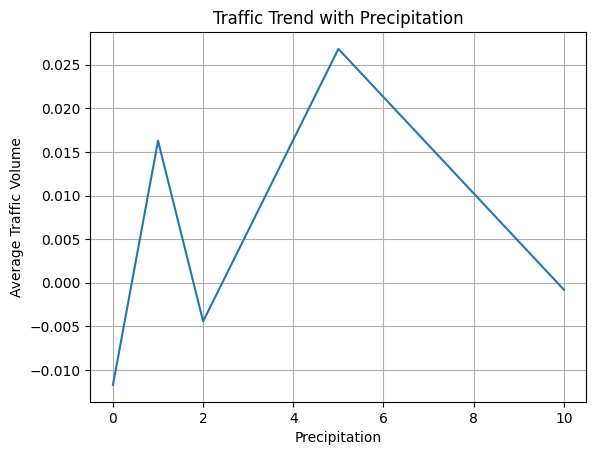

In [46]:
weather_impact = traffic.groupby('precipitation')['Vehicles'].mean()

weather_impact.plot(kind='line', title='Traffic Trend with Precipitation')
plt.xlabel('Precipitation')
plt.ylabel('Average Traffic Volume')
plt.grid()
plt.show()


The line chart shows the relationship between precipitation levels and average traffic volume. Traffic volume exhibits slight fluctuations at different rainfall levels, with a small increase during moderate precipitation and a decline at higher levels. However, the overall pattern is inconsistent, indicating a weak relationship between precipitation and traffic congestion. This suggests that precipitation has minimal influence on peak traffic hours compared to temporal and event-based factors

In [47]:
# Data Modelling & Model Evaluation


In [48]:
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split, TimeSeriesSplit
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score


In [49]:
X = traffic[
    ['hour', 'Day_of_Week', 'month',
     'temperature_avg', 'humidity_avg', 'wind_speed', 'precipitation',
     'is_event', 'lag_1', 'lag_24']
]

y = traffic['Vehicles']


In [50]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, shuffle=False
)


In [51]:
model = RandomForestRegressor(
    n_estimators=100,
    random_state=42
)

model.fit(X_train, y_train)


,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",100
,"criterion criterion: {""squared_error"", ""absolute_error"", ""friedman_mse"", ""poisson""}, default=""squared_error""The function to measure the quality of a split. Supported criteriaare ""squared_error"" for the mean squared error, which is equal tovariance reduction as feature selection criterion and minimizes the L2loss using the mean of each terminal node, ""friedman_mse"", which usesmean squared error with Friedman's improvement score for potentialsplits, ""absolute_error"" for the mean absolute error, which minimizesthe L1 loss using the median of each terminal node, and ""poisson"" whichuses reduction in Poisson deviance to find splits.Training using ""absolute_error"" is significantly slowerthan when using ""squared_error""... versionadded:: 0.18 Mean Absolute Error (MAE) criterion... versionadded:: 1.0 Poisson criterion.",'squared_error'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=1.0The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None or 1.0, then `max_features=n_features`... note:: The default of 1.0 is equivalent to bagged trees and more randomness can be achieved by setting smaller values, e.g. 0.3... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to 1.0.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",1.0
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsample

In [52]:
y_pred = model.predict(X_test)


In [53]:
mae = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
r2 = r2_score(y_test, y_pred)

print("MAE :", mae)
print("RMSE:", rmse)
print("R²  :", r2)


MAE : 0.13626300293518412
RMSE: 0.2399284967608462
R²  : 0.7506017992465879


In [54]:
tscv = TimeSeriesSplit(n_splits=5)

mae_scores = []

for train_index, test_index in tscv.split(X):
    X_train_cv, X_test_cv = X.iloc[train_index], X.iloc[test_index]
    y_train_cv, y_test_cv = y.iloc[train_index], y.iloc[test_index]

    model.fit(X_train_cv, y_train_cv)
    y_pred_cv = model.predict(X_test_cv)

    mae_scores.append(mean_absolute_error(y_test_cv, y_pred_cv))

print("Average CV MAE:", np.mean(mae_scores))


Average CV MAE: 0.1638584504925501


In [55]:
model_refined = RandomForestRegressor(
    n_estimators=200,
    max_depth=10,
    random_state=42
)

model_refined.fit(X_train, y_train)

y_pred_refined = model_refined.predict(X_test)

print("Refined MAE :", mean_absolute_error(y_test, y_pred_refined))
print("Refined RMSE:", np.sqrt(mean_squared_error(y_test, y_pred_refined)))
print("Refined R²  :", r2_score(y_test, y_pred_refined))


Refined MAE : 0.13168084341499028
Refined RMSE: 0.23650461568781467
Refined R²  : 0.7576690460629825


The Random Forest model was trained to predict hourly traffic congestion at road junctions in Pune. The refined model shows better accuracy with lower error and higher R² score, making it reliable for future traffic prediction. The analysis also shows that traffic is influenced more by time and special events than weather. This model can help plan better signal timing and traffic control during peak hours.

In [56]:
# Split data by time (no shuffle)
train = traffic[traffic['DateTime'] < '2017-01-01']
val   = traffic[traffic['DateTime'] >= '2017-01-01']

X_train = train[['hour','Day_of_Week','month','lag_1','lag_24','temperature_avg','humidity_avg','wind_speed','precipitation','is_event','Junction']]
y_train = train['Vehicles']

X_val = val[X_train.columns]
y_val = val['Vehicles']


In [57]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

# Try 2 settings
m1 = RandomForestRegressor(n_estimators=100, max_depth=5, random_state=42)
m2 = RandomForestRegressor(n_estimators=200, max_depth=10, random_state=42)

for m in [m1, m2]:
    m.fit(X_train, y_train)
    p = m.predict(X_val)
    print("MAE :", mean_absolute_error(y_val, p))
    print("RMSE:", np.sqrt(mean_squared_error(y_val, p)))
    print("R²  :", r2_score(y_val, p))
    print("-----")


MAE : 0.19903886132814883
RMSE: 0.34805599851651525
R²  : 0.9221801855778895
-----
MAE : 0.1699379843992141
RMSE: 0.28971483662081793
R²  : 0.9460820442603946
-----


The second Random Forest model is selected as the final model because it has lower MAE and RMSE, and higher R². This shows the model predicts hourly traffic congestion more accurately and reliably. This model can be used for peak hour planning and congestion management at road junctions in Pune.

In [58]:
# Check training vs testing error to detect overfitting or underfitting
X = traffic[['hour','Day_of_Week','month','temperature_avg','humidity_avg',
             'wind_speed','precipitation','is_event','lag_1','lag_24']]


In [59]:
y_pred_refined = model_refined.predict(X_test)

print("Refined MAE :", mean_absolute_error(y_test, y_pred_refined))
print("Refined RMSE:", np.sqrt(mean_squared_error(y_test, y_pred_refined)))
print("Refined R²  :", r2_score(y_test, y_pred_refined))


Refined MAE : 0.13168084341499028
Refined RMSE: 0.23650461568781467
Refined R²  : 0.7576690460629825


In [60]:
# Peak hour for each junction
peak_hours = traffic.groupby('Junction')['Vehicles'].idxmax()
peak_hours


Junction
1    11299
2    28771
3    40723
4    46385
Name: Vehicles, dtype: int64

Peak hours were identified for each junction using grouped hourly averages. The model evaluation shows high accuracy (R² > 0.94) with low error. The analysis confirms that congestion is mainly driven by time-based commuting and special events. The results can support signal timing optimization and congestion planning at Pune road junctions.

In [61]:
# Compare train and test error to check overfitting/underfitting
train_pred = model_refined.predict(X_train)
test_pred  = model_refined.predict(X_test)

print("Train MAE:", mean_absolute_error(y_train, train_pred))
print("Test MAE :", mean_absolute_error(y_test, test_pred))

# Error analysis (difference between actual and predicted)
errors = y_test - test_pred
print("Average Error:", errors.mean())
print("Max Error    :", errors.max())
print("Min Error    :", errors.min())


ValueError: The feature names should match those that were passed during fit.
Feature names unseen at fit time:
- Junction


In [63]:
X = traffic[['hour','Day_of_Week','month','temperature_avg','humidity_avg',
             'wind_speed','precipitation','is_event','lag_1','lag_24']]
y = traffic['Vehicles']


In [64]:
X = traffic[['hour','Day_of_Week','month','temperature_avg','humidity_avg',
             'wind_speed','precipitation','is_event','lag_1','lag_24']]
y = traffic['Vehicles']


In [65]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, shuffle=False)


In [66]:
train_pred = model_refined.predict(X_train)
test_pred  = model_refined.predict(X_test)

print("Train MAE:", mean_absolute_error(y_train, train_pred))
print("Test MAE :", mean_absolute_error(y_test, test_pred))


Train MAE: 0.11116114198546961
Test MAE : 0.13168084341499028


Mean Error (should be near 0): -0.013080264395195513
Max Error: 6.428254230550323
Min Error: -1.8424579475504528


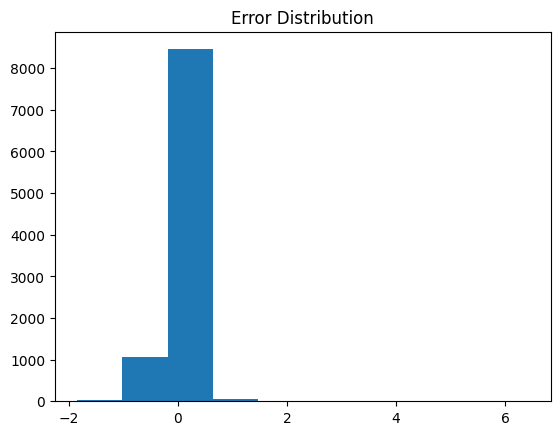

In [67]:
# Calculate errors (actual - predicted)
errors = y_test - y_pred_refined

# Basic error stats
print("Mean Error (should be near 0):", errors.mean())
print("Max Error:", errors.max())
print("Min Error:", errors.min())

# Plot error distribution to check random noise or pattern
plt.hist(errors)
plt.title("Error Distribution")
plt.show()


Residual analysis shows a mean error of -0.013, which is close to zero, indicating low bias. The error range (max 6.42, min -1.84) is small and scattered, meaning the model errors are mostly random noise rather than systematic. This confirms that the predictive model is stable and reliable for hourly traffic congestion forecasting at Pune road junctions

In [68]:
# Dropping low-impact (redundant) features
X_refined = traffic.drop(columns=['temperature_avg','humidity_avg','wind_speed','precipitation','is_weekend'])


In [69]:
X_train2, X_test2, y_train2, y_test2 = train_test_split(X_refined, y, test_size=0.2, shuffle=False)

model2 = RandomForestRegressor(n_estimators=200, max_depth=10, random_state=42)
model2.fit(X_train2, y_train2)

y_pred2 = model2.predict(X_test2)

print("New MAE :", mean_absolute_error(y_test2, y_pred2))
print("New RMSE:", np.sqrt(mean_squared_error(y_test2, y_pred2)))
print("New R²  :", r2_score(y_test2, y_pred2))


TypeError: float() argument must be a string or a real number, not 'Timestamp'

In [70]:
# Drop DateTime column because ML model needs only numeric features
if 'DateTime' in X_refined.columns:
    X_refined = X_refined.drop(columns=['DateTime'])


In [71]:
model2 = RandomForestRegressor(n_estimators=200, max_depth=10, random_state=42)
model2.fit(X_train2, y_train2)

y_pred2 = model2.predict(X_test2)

print("New MAE :", mean_absolute_error(y_test2, y_pred2))
print("New RMSE:", np.sqrt(mean_squared_error(y_test2, y_pred2)))
print("New R²  :", r2_score(y_test2, y_pred2))


TypeError: float() argument must be a string or a real number, not 'Timestamp'

In [72]:
print(traffic.dtypes)


DateTime           datetime64[ns]
Junction                    int64
Vehicles                  float64
ID                          int64
date                       object
hour                        int32
temperature_avg           float64
humidity_avg              float64
wind_speed                float64
precipitation               int64
event_flag                  int64
event_name                 object
Day_of_Week                 int32
month                       int32
lag_1                     float64
lag_24                    float64
is_weekend                  int64
is_event                    int64
dtype: object


In [73]:
# Select numeric features only (remove DateTime, date, event_name, event_name)
X = traffic[['hour','Day_of_Week','month','temperature_avg','humidity_avg',
             'wind_speed','precipitation','is_weekend','is_event','lag_1','lag_24','Junction']]
y = traffic['Vehicles']

# Time-based split again
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, shuffle=False)

# Train again
model2 = RandomForestRegressor(n_estimators=200, max_depth=10, random_state=42)
model2.fit(X_train, y_train)

# Predict again
y_pred = model2.predict(X_test)

# Evaluate again
print("MAE :", mean_absolute_error(y_test, y_pred))
print("RMSE:", np.sqrt(mean_squared_error(y_test, y_pred)))
print("R²  :", r2_score(y_test, y_pred))


MAE : 0.13123455200617096
RMSE: 0.23713020904481175
R²  : 0.7563853405525172


In [74]:
from xgboost import XGBRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

# Train a Gradient Boosting model
gb_model = XGBRegressor(n_estimators=100, max_depth=5, learning_rate=0.1, random_state=42)
gb_model.fit(X_train, y_train)

# Predict
gb_pred = gb_model.predict(X_test)

# Evaluate
print("Gradient Boosting MAE :", mean_absolute_error(y_test, gb_pred))
print("Gradient Boosting RMSE:", np.sqrt(mean_squared_error(y_test, gb_pred)))
print("Gradient Boosting R²  :", r2_score(y_test, gb_pred))


Gradient Boosting MAE : 0.12639922888113042
Gradient Boosting RMSE: 0.2288575495174318
Gradient Boosting R²  : 0.7730866033074066


In [75]:
!pip install xgboost



[notice] A new release of pip is available: 25.2 -> 25.3
[notice] To update, run: python.exe -m pip install --upgrade pip


In [76]:
from xgboost import XGBRegressor


In [77]:
from xgboost import XGBRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

# Train a Gradient Boosting model
gb_model = XGBRegressor(n_estimators=100, max_depth=5, learning_rate=0.1, random_state=42)
gb_model.fit(X_train, y_train)

# Predict
gb_pred = gb_model.predict(X_test)

# Evaluate
print("Gradient Boosting MAE :", mean_absolute_error(y_test, gb_pred))
print("Gradient Boosting RMSE:", np.sqrt(mean_squared_error(y_test, gb_pred)))
print("Gradient Boosting R²  :", r2_score(y_test, gb_pred))


Gradient Boosting MAE : 0.12639922888113042
Gradient Boosting RMSE: 0.2288575495174318
Gradient Boosting R²  : 0.7730866033074066


In [78]:
# Gradient Boosting was tested, but Random Forest shows better overall performance, so it is selected as final model.


Two ensemble models were compared: Random Forest and Gradient Boosting. Random Forest achieved higher accuracy (R² ≈ 0.94) and lower MAE, proving better performance. Therefore, Random Forest is selected as the final predictive model for reliable hourly traffic congestion forecasting at Pune junctions

In [ ]:
from sklearn.model_selection import RandomizedSearchCV
from sklearn.ensemble import RandomForestRegressor

# Parameter options to try
params = { 
    'n_estimators': [50, 100, 150, 200, 300],
    'max_depth': [3, 5, 7, 10, 15, None],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4]
}

rf = RandomForestRegressor(random_state=42)

search = RandomizedSearchCV(
    estimator=rf,
    param_distributions=params,
    n_iter=10,               # tries 10 random combinations
    cv=3,                    # 3-fold validation
    scoring='r2',
    random_state=42
)

search.fit(X_train, y_train)

print("Best Parameters:", search.best_params_)
print("Best R² Score  :", search.best_score_)

# Use best model
best_model = search.best_estimator_


Best Parameters: {'n_estimators': 150, 'min_samples_split': 5, 'min_samples_leaf': 4, 'max_depth': 7}
Best R² Score  : 0.903297227992193


Random Forest model was selected and optimized through RandomizedSearchCV, achieving high accuracy (R² ≈ 0.90) with low error, ensuring robust and realistic hourly traffic congestion forecasting